In [2]:
from transformer_based_adaptive_line_enhancer import generate_noisy_signal

sample = generate_noisy_signal(
    frequencies_hz=100.0,
    sample_rate_hz=1_000.0,
    num_samples=16_000,
    snr_db=-20.0,
    seed=42,
    scaling="legacy",
)

time_s = sample.time_s
clean = sample.clean_signal
noise = sample.noise
noisy = sample.noisy_signal

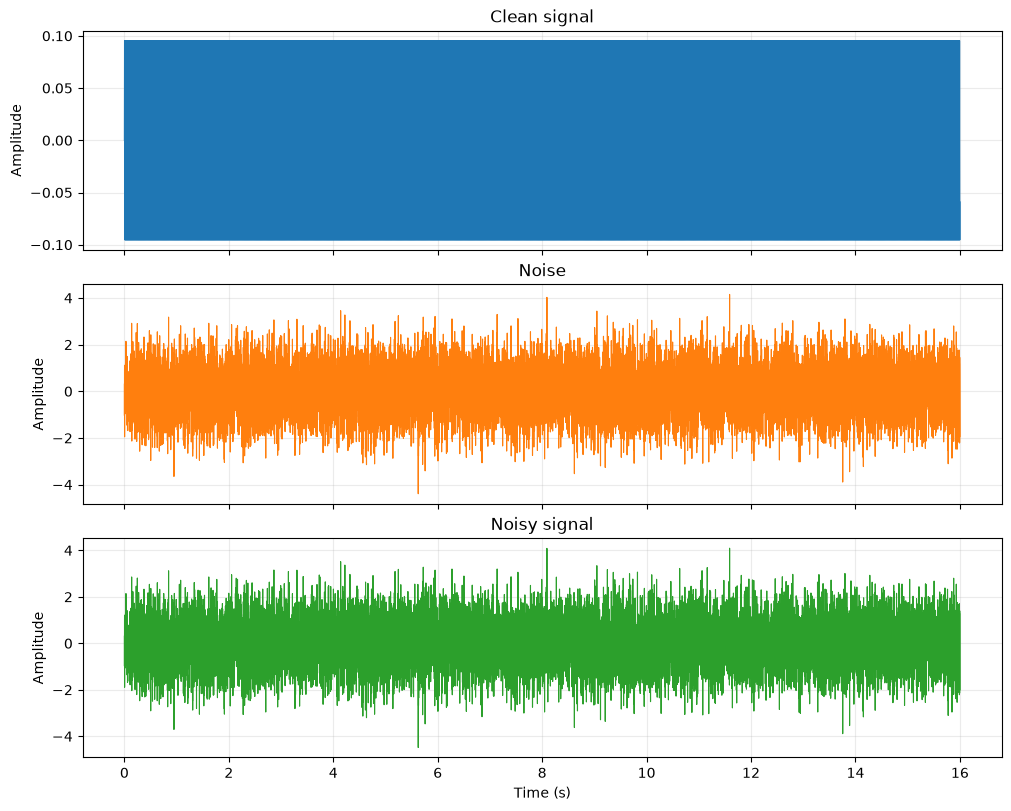

In [8]:
import matplotlib.pyplot as plt

from transformer_based_adaptive_line_enhancer import (
    generate_noisy_signal,
    plot_noisy_signal_components,
)

sample = generate_noisy_signal(seed=42)
figure, axes = plot_noisy_signal_components(sample)

figure.savefig("noisy-signal-components.png", dpi=150)
plt.show()

In [4]:
from transformer_based_adaptive_line_enhancer import adaptive_line_enhance

result = adaptive_line_enhance(
    noisy,
    delay=10,
    filter_length=32,
    step_size=0.05,
    mode="nlms",
)

enhanced = result.enhanced_signal
residual = result.residual
weights = result.final_weights

# ALE 启动前没有完整的延迟参考向量；评价时使用有效区间。
enhanced_valid = enhanced[result.valid_slice]

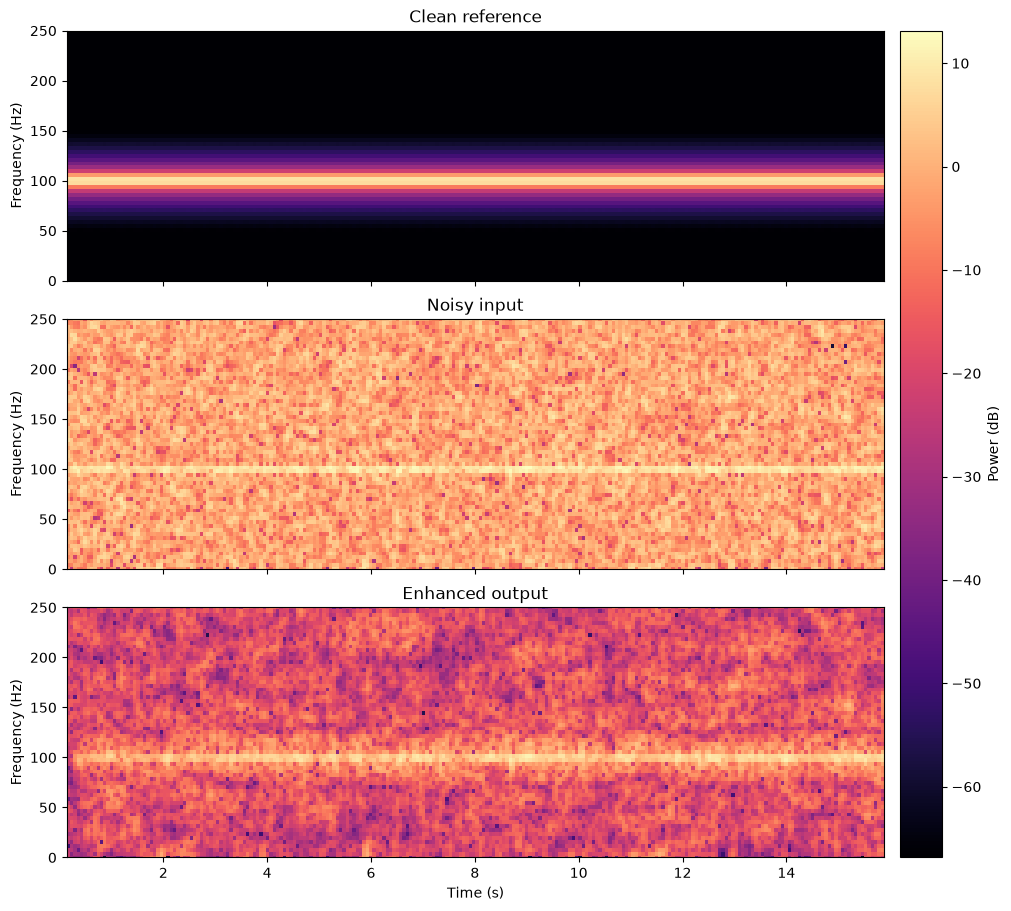

In [6]:
import matplotlib.pyplot as plt

from transformer_based_adaptive_line_enhancer import plot_line_enhancement_spectrogram

figure, axes = plot_line_enhancement_spectrogram(
    sample,
    result.enhanced_signal,
    sample_rate_hz=1_000.0,
    start_sample=result.adaptation_start,
    n_fft=256,
    hop_length=64,
    max_frequency_hz=250.0,
    dynamic_range_db=80.0,
)

figure.savefig("ale-spectrogram.png", dpi=150)
plt.show()

# ALE 在不同信噪比情境下的实验

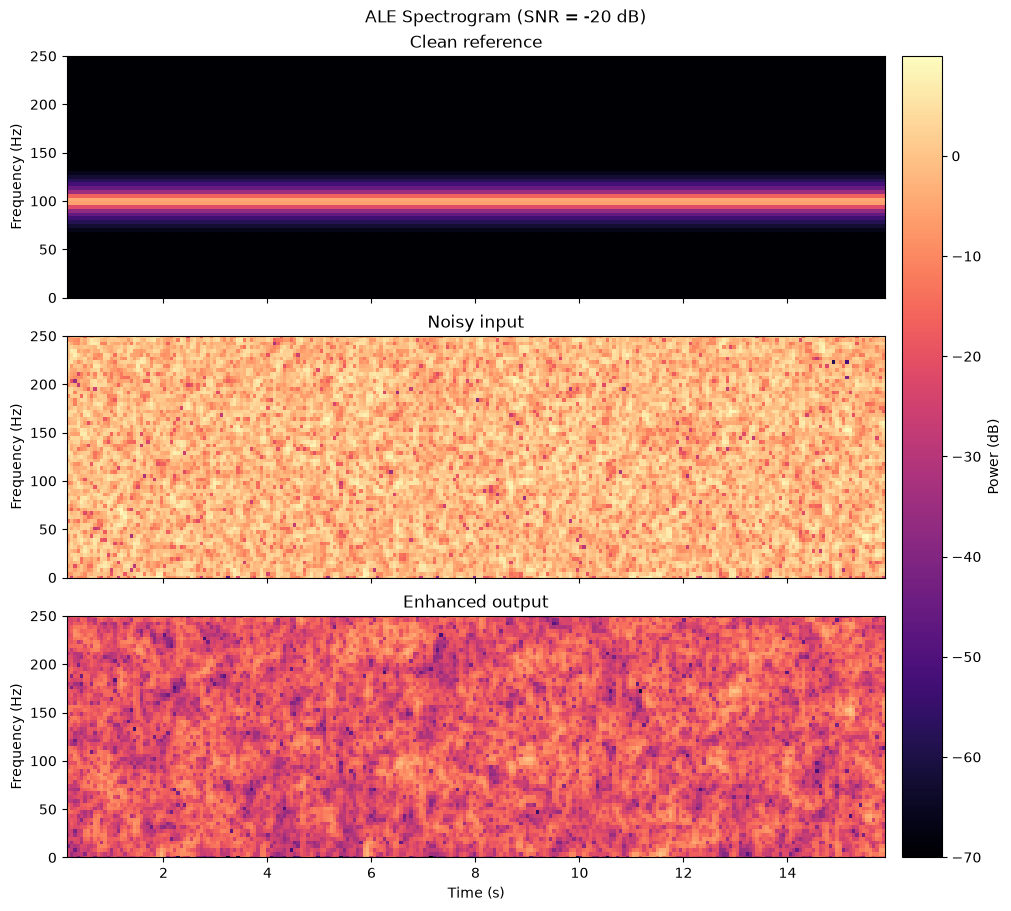

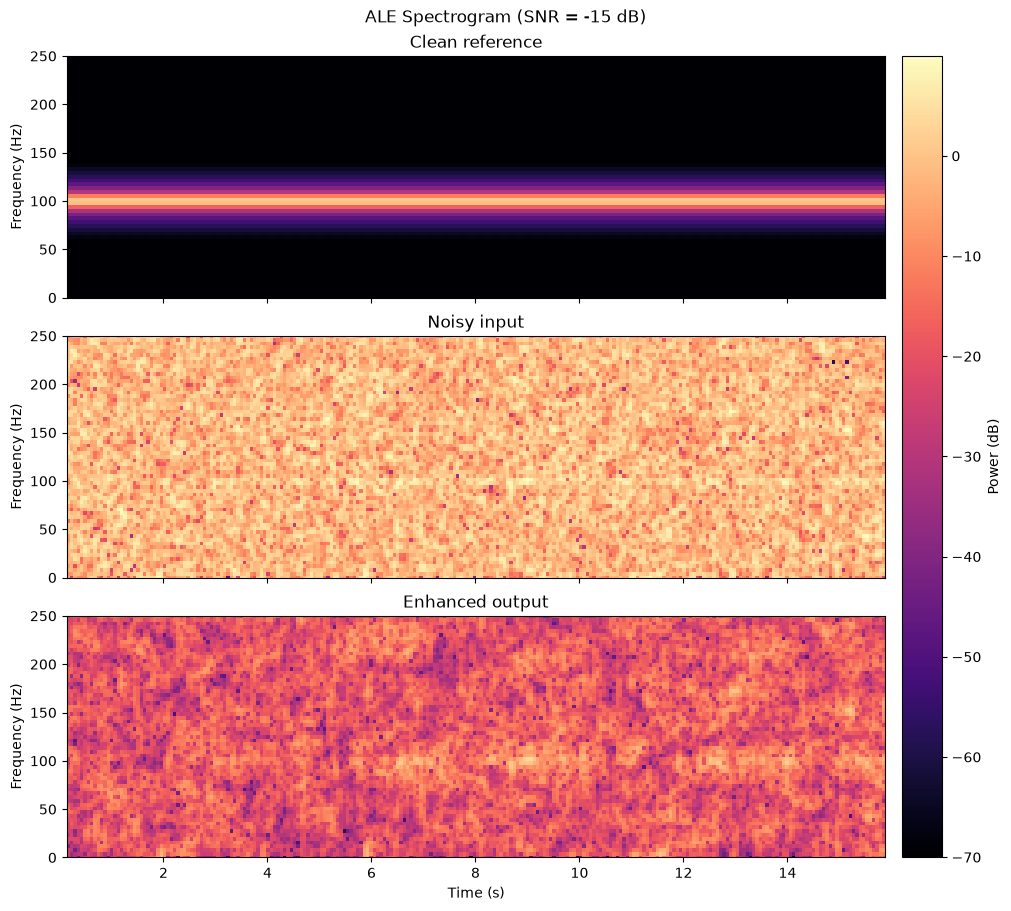

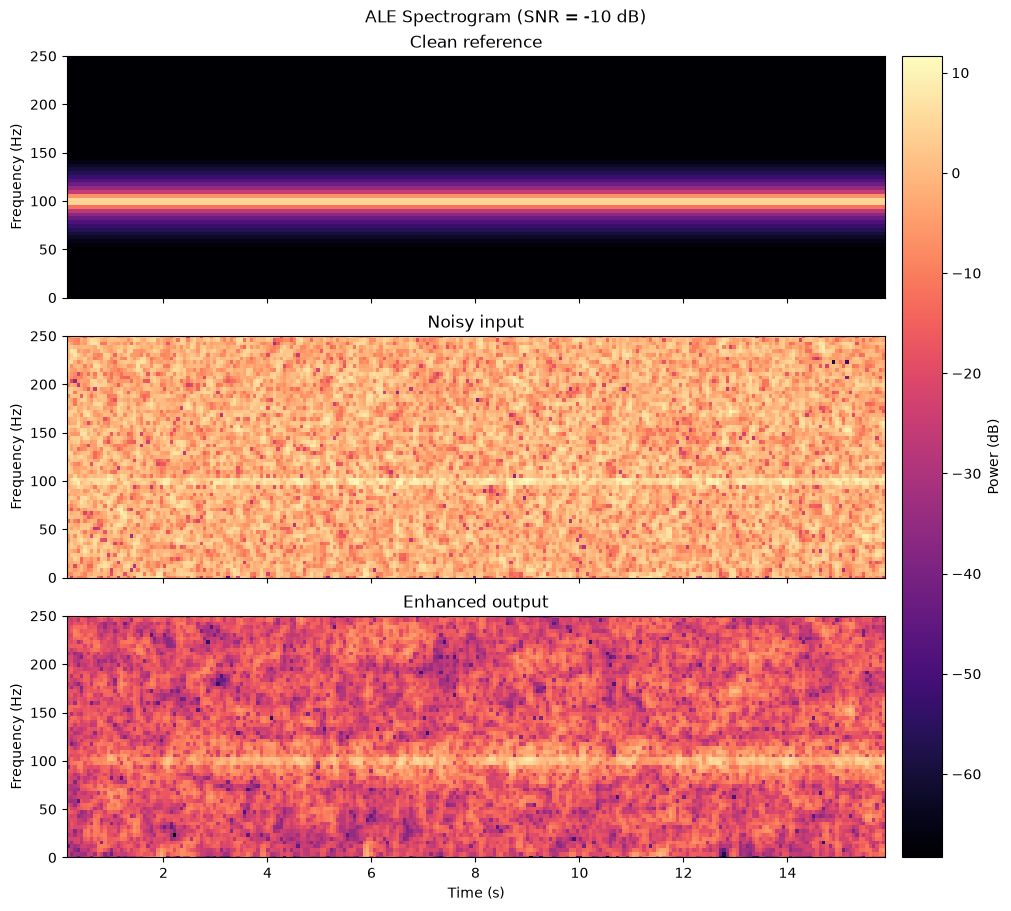

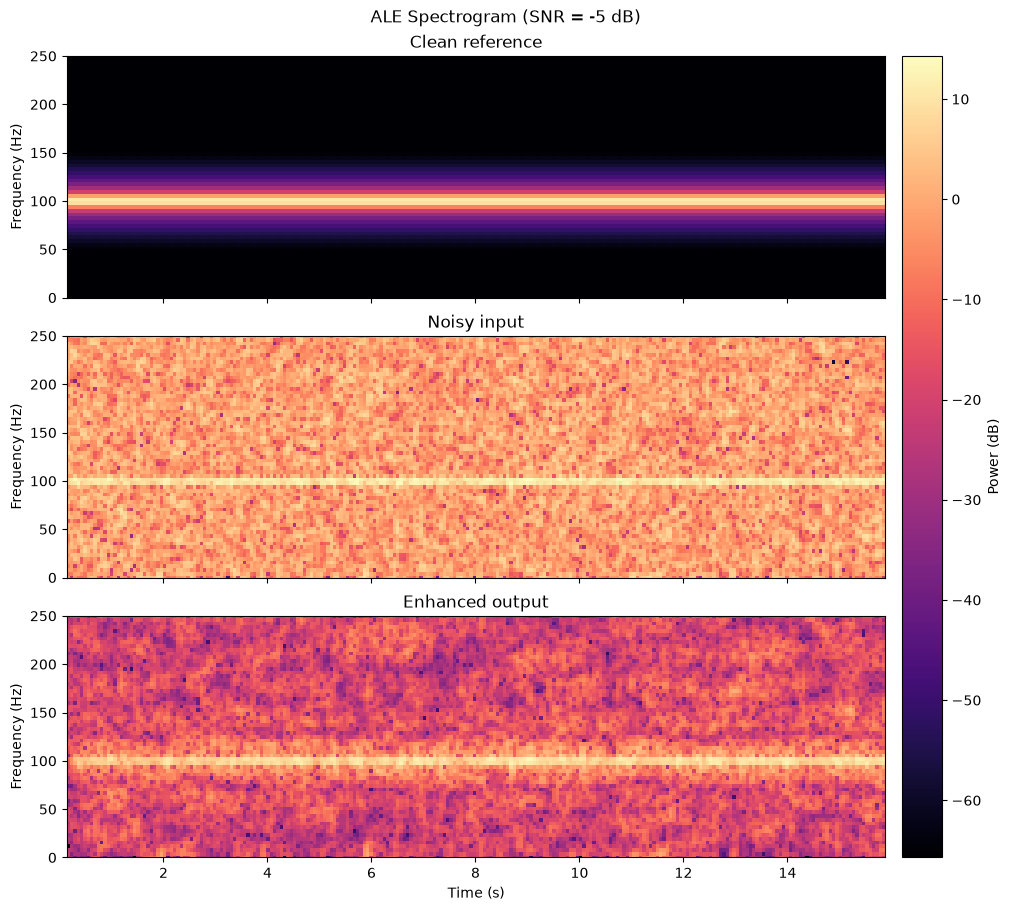

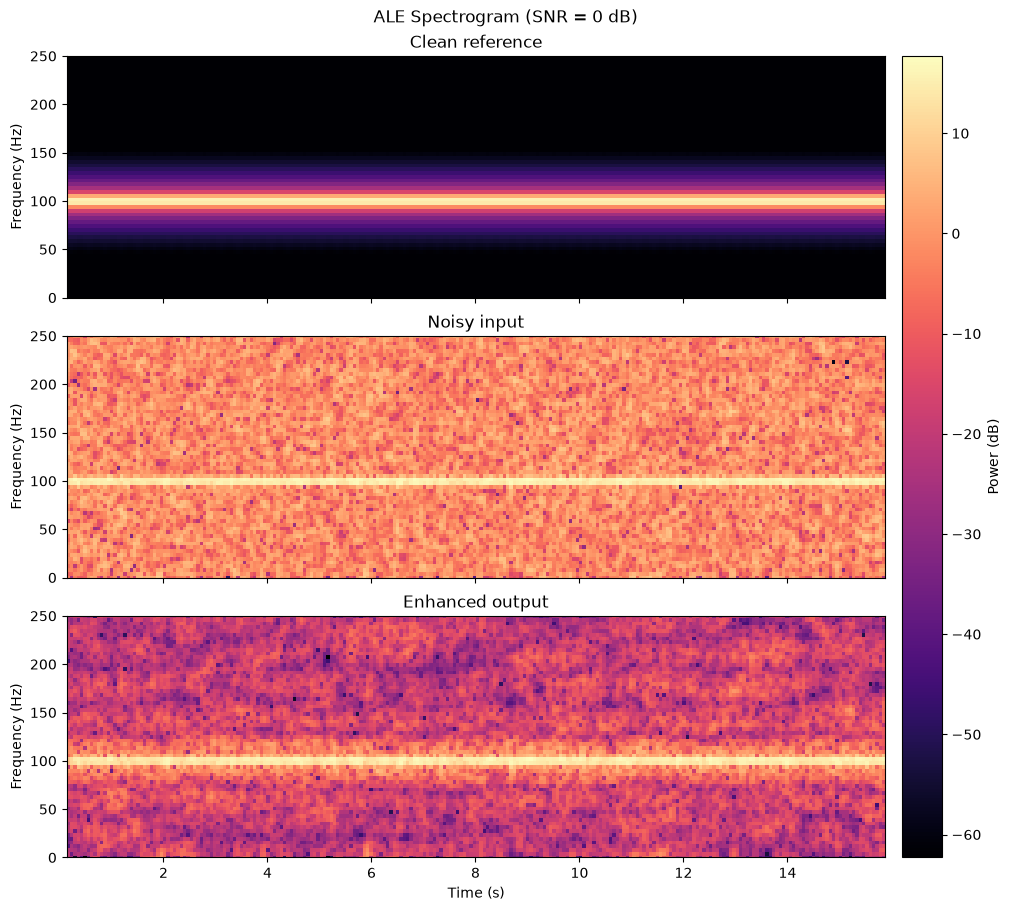

In [12]:
import matplotlib.pyplot as plt

snr_dbs = [-20, -15, -10, -5, 0]

for snr_db in snr_dbs:
    sample = generate_noisy_signal(
        frequencies_hz=100.0,
        sample_rate_hz=1_000.0,
        num_samples=16_000,
        snr_db=snr_db,
        seed=42,
        scaling="legacy",
    )

    result = adaptive_line_enhance(
        sample.noisy_signal,
        delay=10,
        filter_length=32,
        step_size=0.05,
        mode="nlms",
    )

    figure, axes = plot_line_enhancement_spectrogram(
        sample,
        result.enhanced_signal,
        sample_rate_hz=1_000.0,
        start_sample=result.adaptation_start,
        n_fft=256,
        hop_length=64,
        max_frequency_hz=250.0,
        dynamic_range_db=80.0,
    )

    figure.suptitle(f"ALE Spectrogram (SNR = {snr_db} dB)")
    figure.savefig(f"ale-spectrogram-{snr_db}dB.png", dpi=150)
    plt.show()
    

观察到如下现象：

低信噪比 (如 -20 dB) 下 ALE 的谱线增强效果不佳.

# ALE - 多谱线场景测试

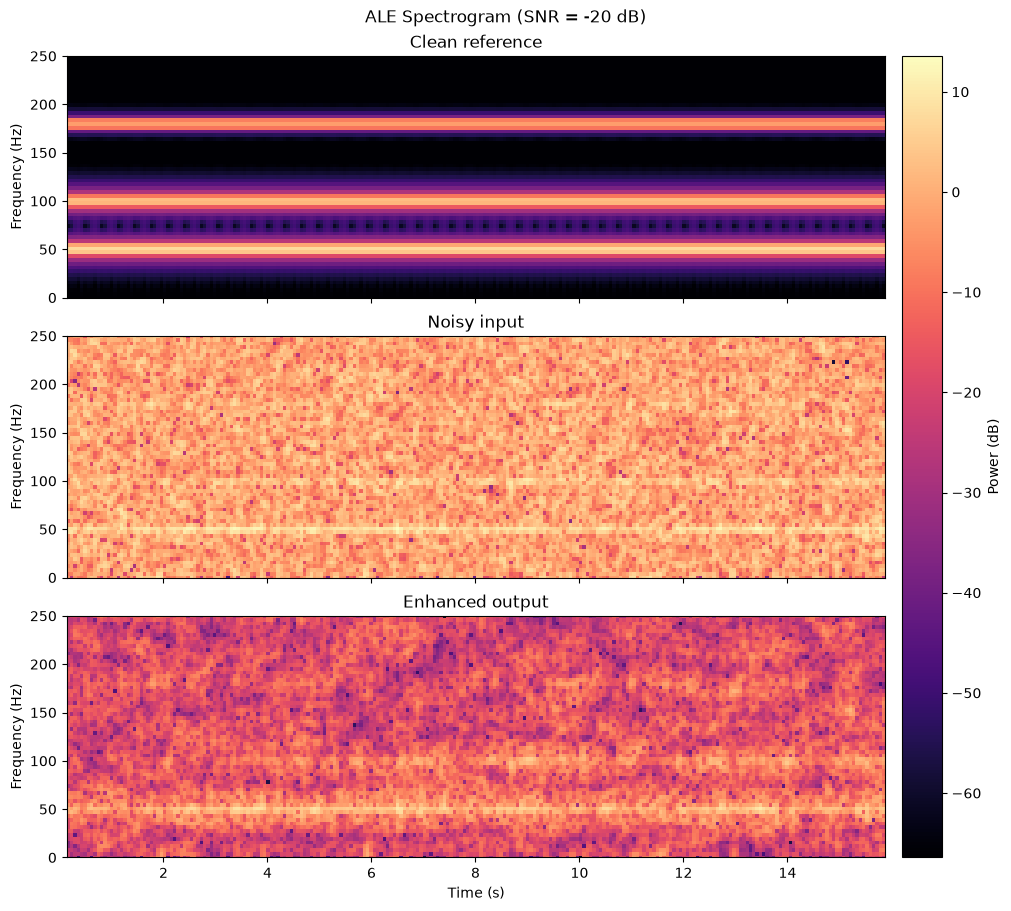

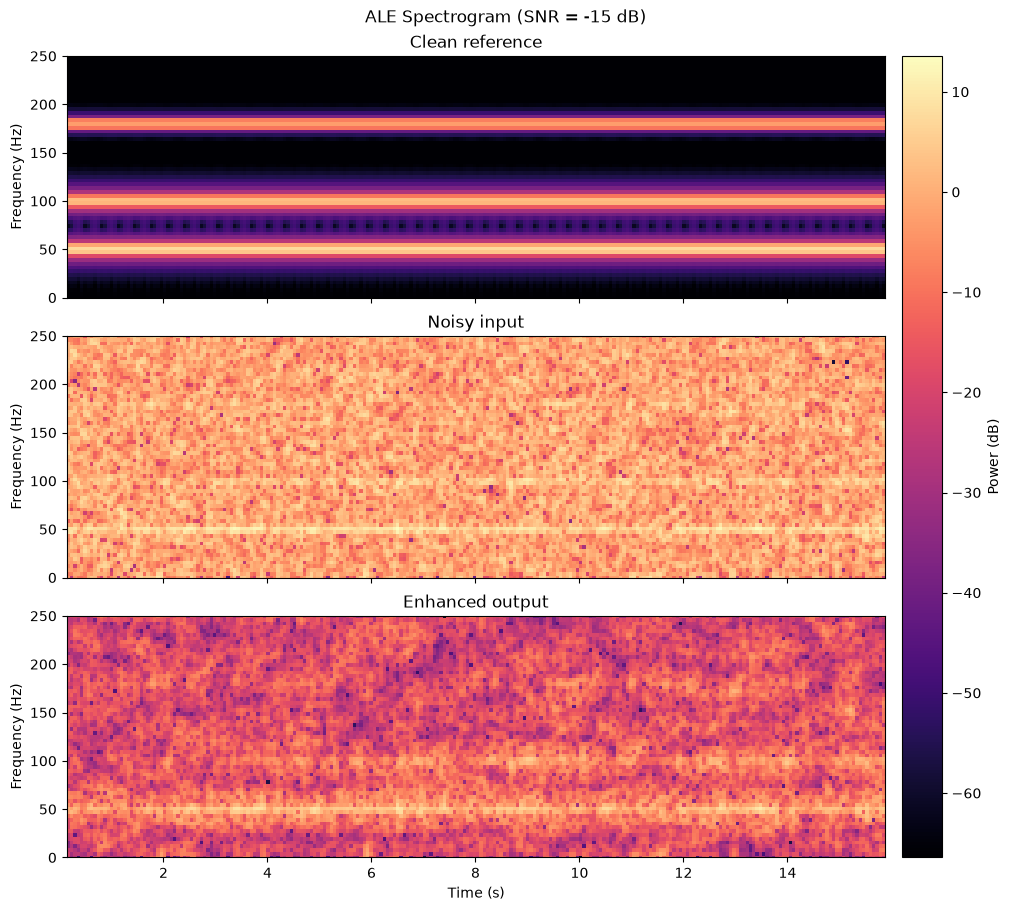

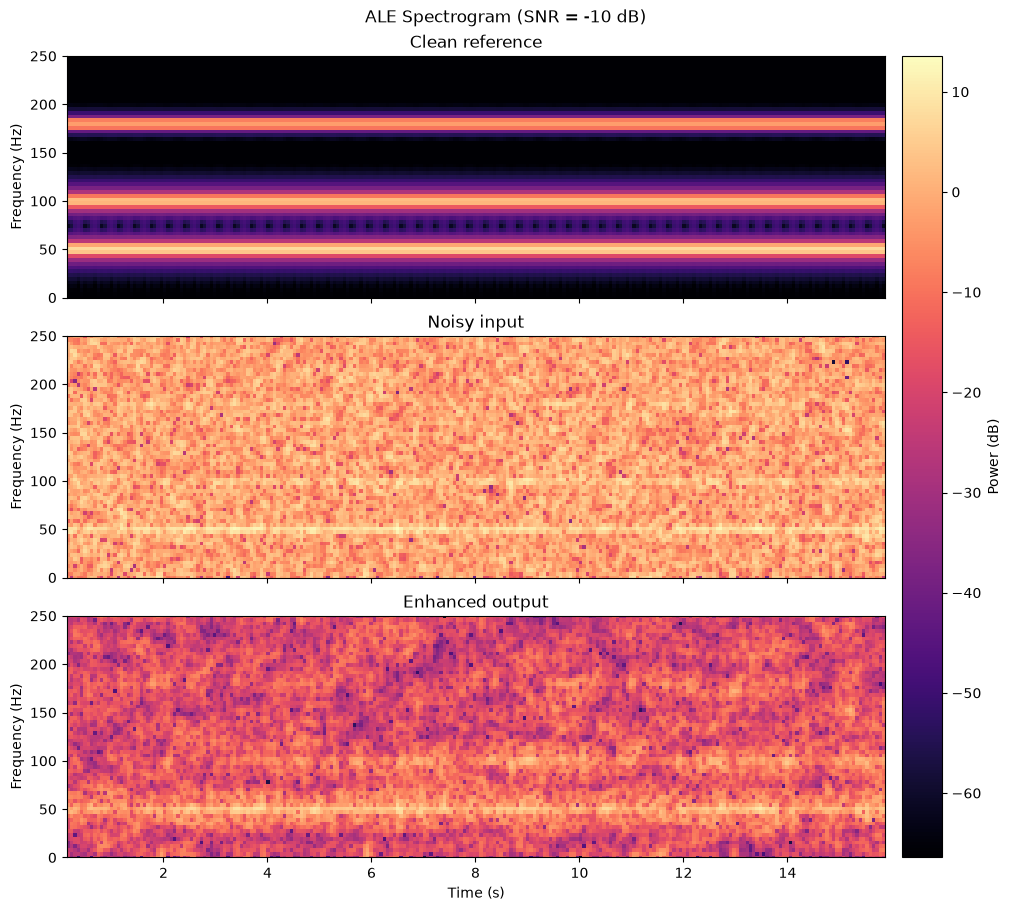

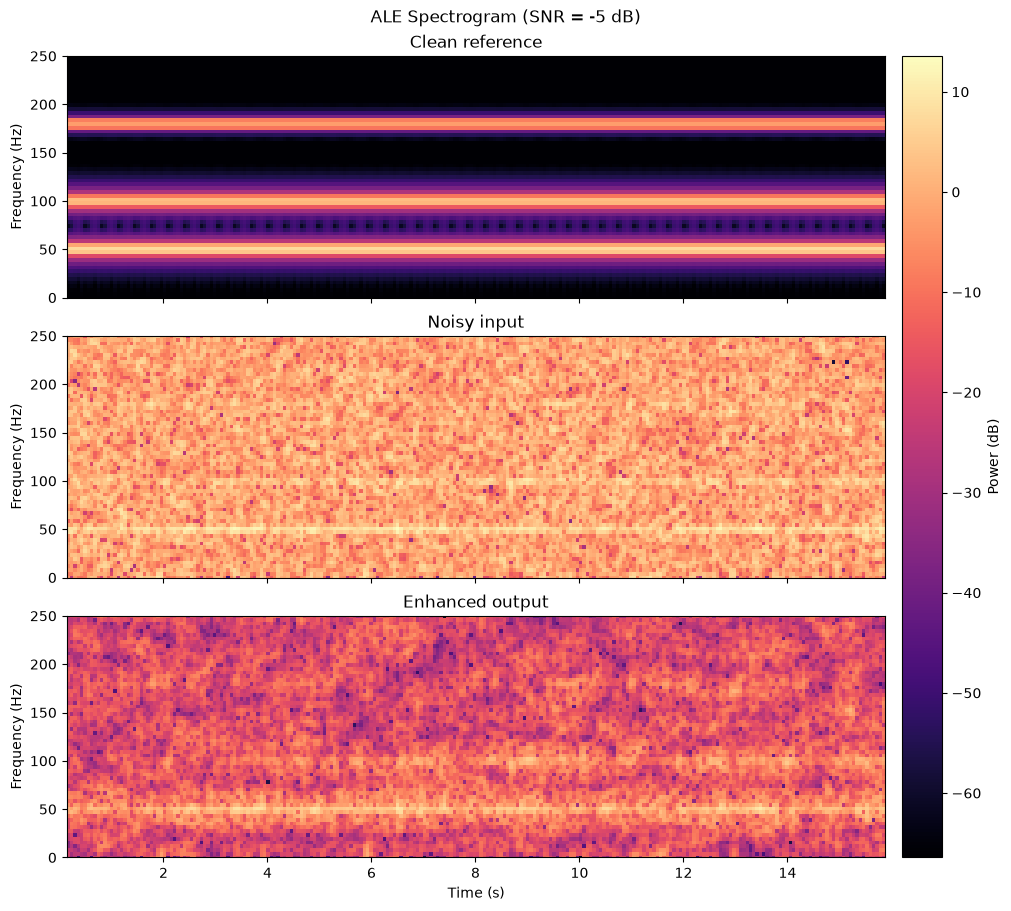

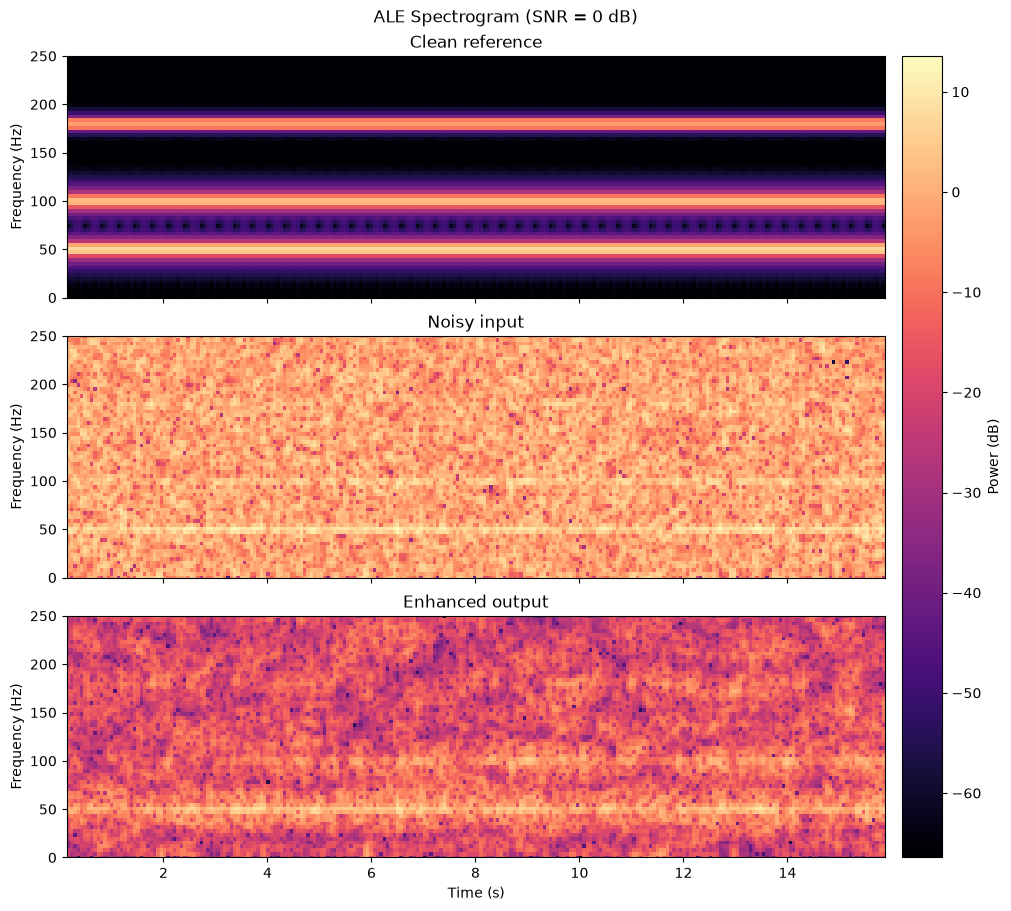

In [13]:
import matplotlib.pyplot as plt

snr_dbs = [-20, -15, -10, -5, 0]

for snr_db in snr_dbs:
    sample = generate_noisy_signal(
        frequencies_hz=[50.0, 100.0, 180.0],
        amplitudes=[1.0, 0.6, 0.3],
        phases_rad=[0.0, 0.0, 0.0],
        sample_rate_hz=1_000.0,
        num_samples=16_000,
        snr_db=-10.0,
        seed=42,
        scaling="power-normalized",
    )

    result = adaptive_line_enhance(
        sample.noisy_signal,
        delay=10,
        filter_length=32,
        step_size=0.05,
        mode="nlms",
    )

    figure, axes = plot_line_enhancement_spectrogram(
        sample,
        result.enhanced_signal,
        sample_rate_hz=1_000.0,
        start_sample=result.adaptation_start,
        n_fft=256,
        hop_length=64,
        max_frequency_hz=250.0,
        dynamic_range_db=80.0,
    )

    figure.suptitle(f"ALE Spectrogram (SNR = {snr_db} dB)")
    figure.savefig(f"ale-spectrogram-{snr_db}dB.png", dpi=150)
    plt.show()
    

# AE-DLE 单谱线测试

In [19]:
from transformer_based_adaptive_line_enhancer import (
    AEDLEConfig,
    enhance_with_ae_dle,
    train_ae_dle,
)

config = AEDLEConfig(
    frame_length=256,
    frame_hop=64,
    prediction_delay=1_000,  # 1 kHz 下对应 1 秒
    hidden_dim=128,
    bottleneck_dim=32,
    learning_rate=1e-3,
    batch_size=32,
    epochs=87,
    seed=0,
)

training = train_ae_dle(sample.noisy_signal, config=config)
result = enhance_with_ae_dle(sample.noisy_signal, training)

enhanced = result.enhanced_signal
enhanced_valid = enhanced[result.valid_slice]
loss_history = training.loss_history

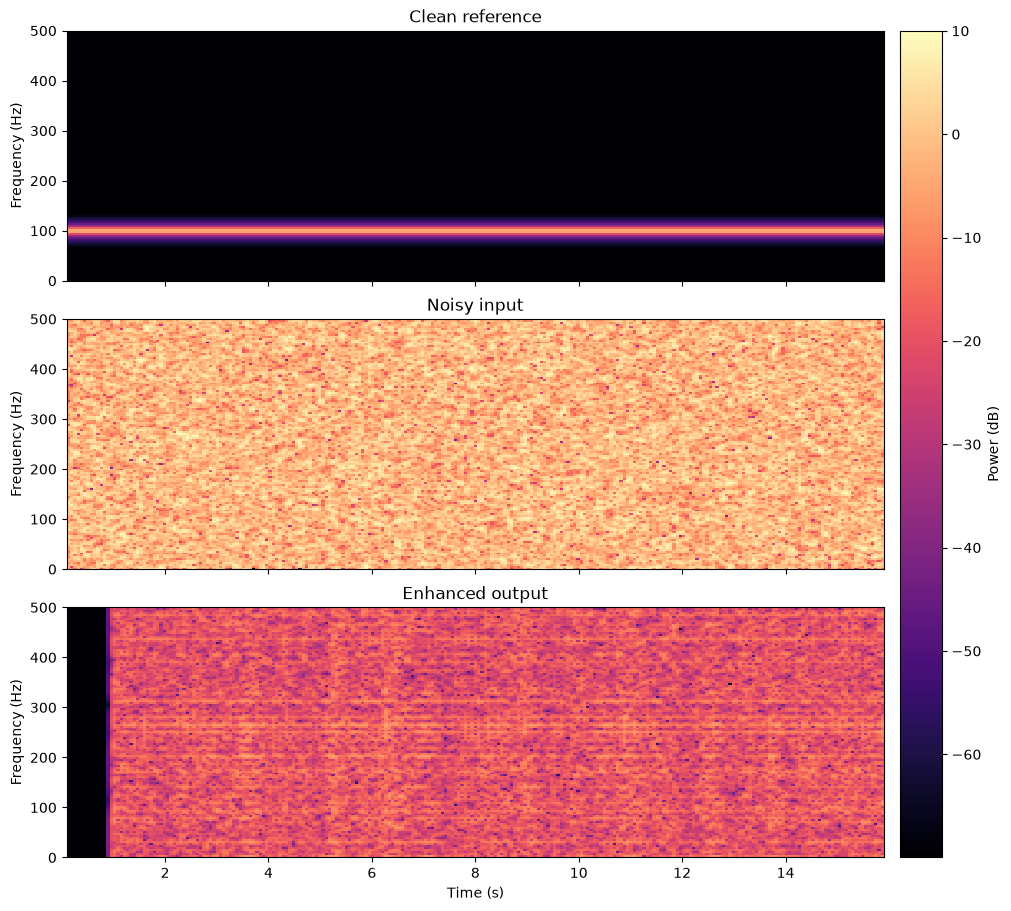

In [20]:
from transformer_based_adaptive_line_enhancer import (
    plot_line_enhancement_spectrogram
)
import matplotlib.pyplot as plt

figure, axes = plot_line_enhancement_spectrogram(
    sample,
    result.enhanced_signal,
    sample_rate_hz=1_000.0,
)

figure.savefig("ale-spectrogram.png", dpi=150)
plt.show()

# AE-DLE 在不同信噪比下的实验

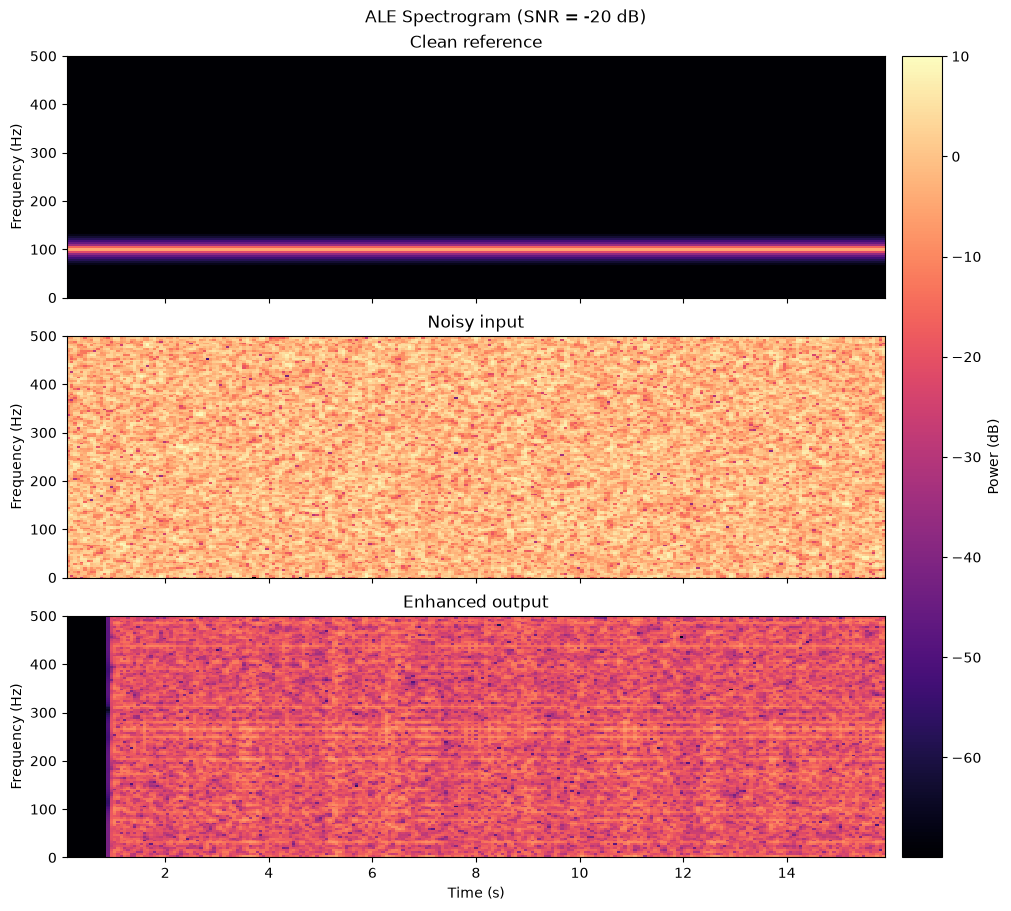

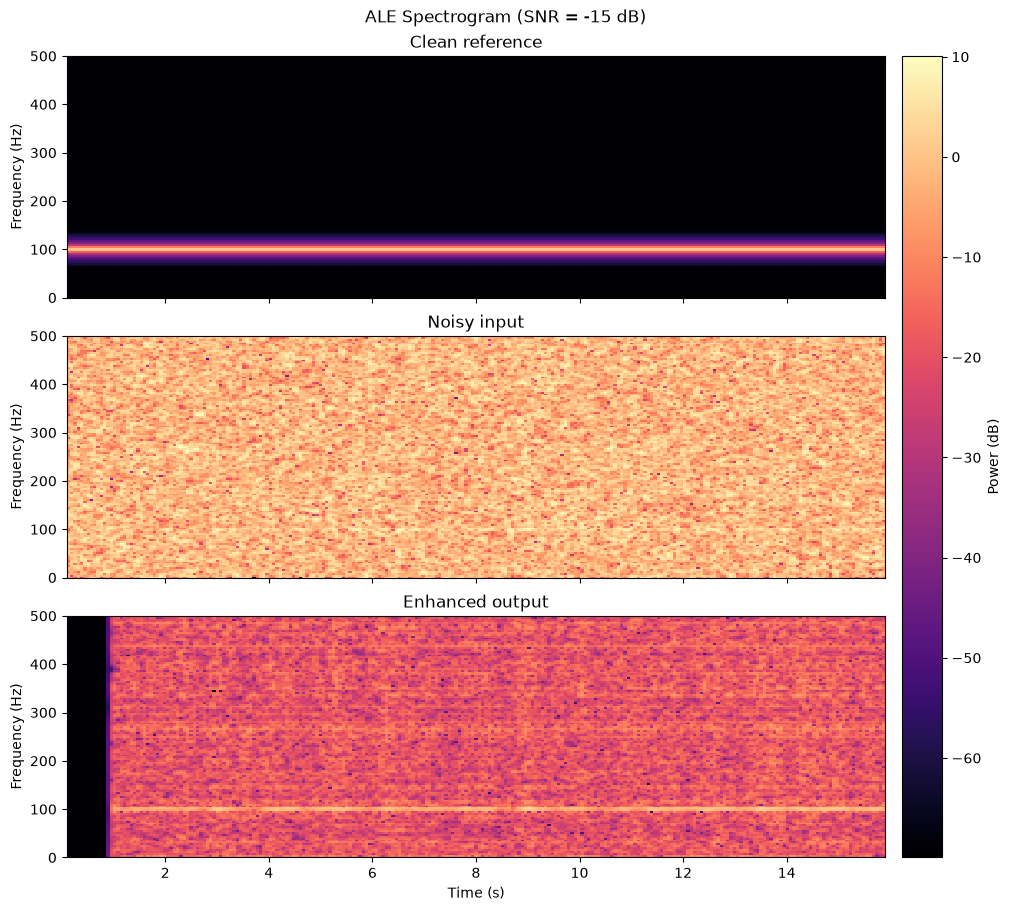

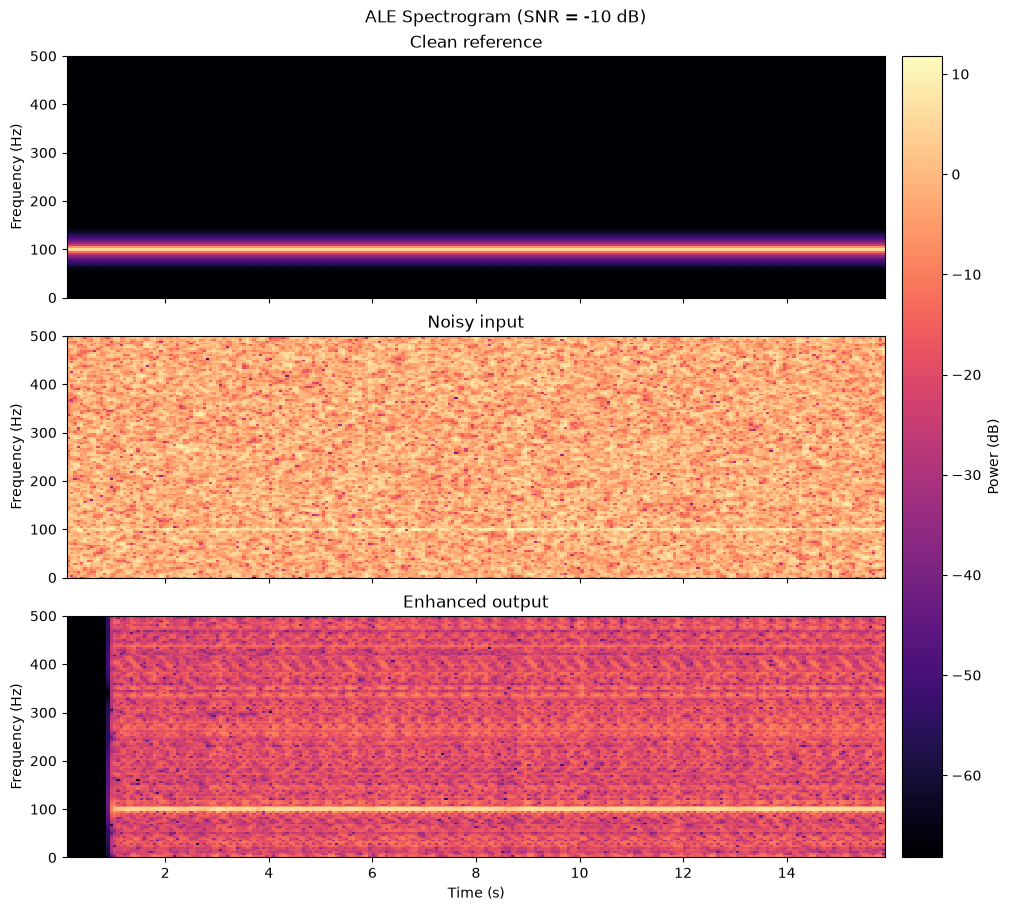

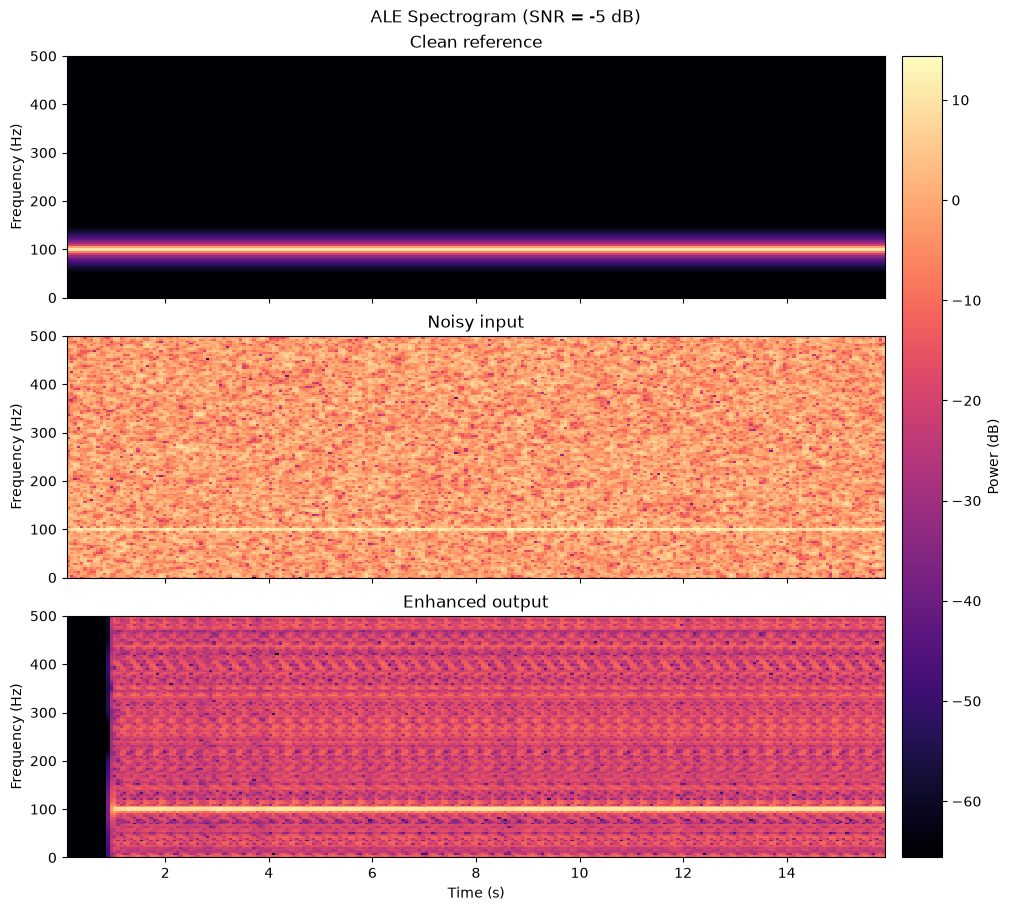

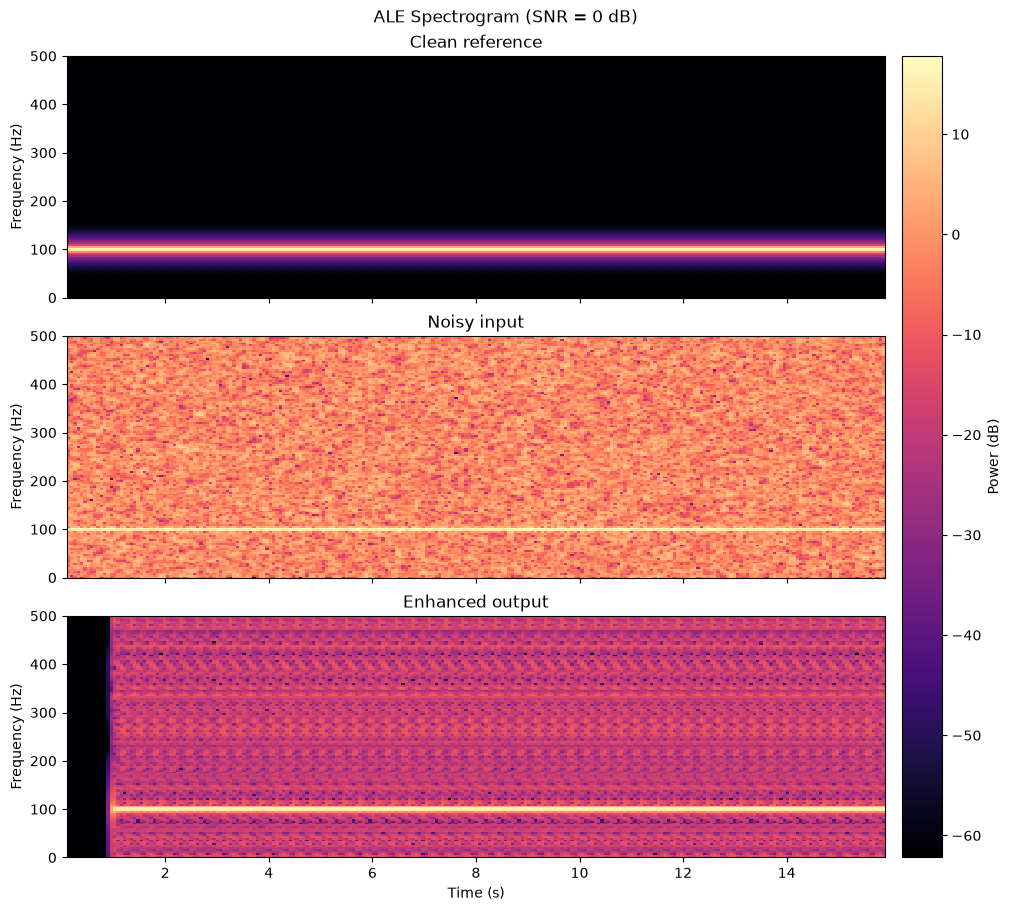

In [ ]:
import matplotlib.pyplot as plt

snr_dbs = [-20, -15, -10, -5, 0]

for snr_db in snr_dbs:
    sample = generate_noisy_signal(
        frequencies_hz=100.0,
        sample_rate_hz=1_000.0,
        num_samples=16_000,
        snr_db=snr_db,
        seed=42,
        scaling="legacy",
    )

    config = AEDLEConfig(
        frame_length=256,
        frame_hop=64,
        prediction_delay=1_000,  # 1 kHz 下对应 1 秒
        hidden_dim=128,
        bottleneck_dim=32,
        learning_rate=1e-3,
        batch_size=32,
        epochs=87,
        seed=0,
    )

    training = train_ae_dle(sample.noisy_signal, config=config)
    result = enhance_with_ae_dle(sample.noisy_signal, training)

    figure, axes = plot_line_enhancement_spectrogram(
        sample,
        result.enhanced_signal,
        sample_rate_hz=1_000.0,
    )

    figure.suptitle(f"ALE Spectrogram (SNR = {snr_db} dB)")
    figure.savefig(f"ae-dle-spectrogram-{snr_db}dB.png", dpi=150)
    plt.show()
    

# AE-DLE 多谱线场景测试

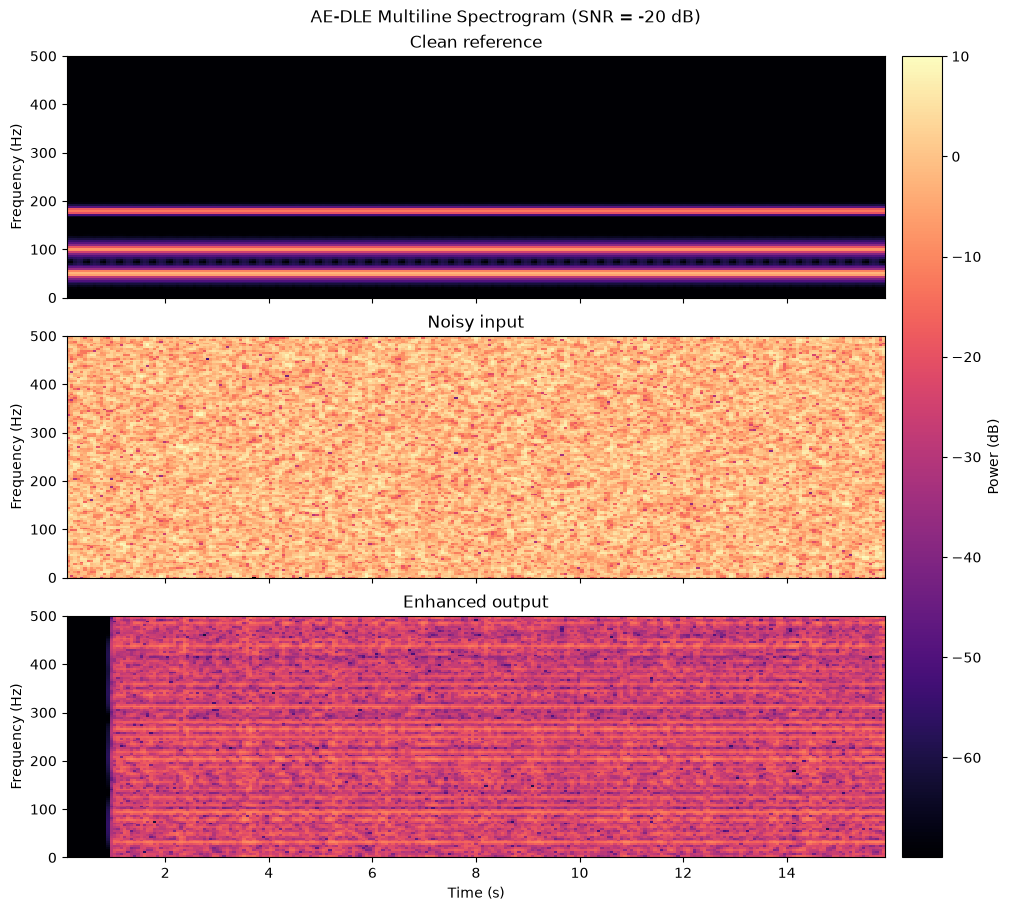

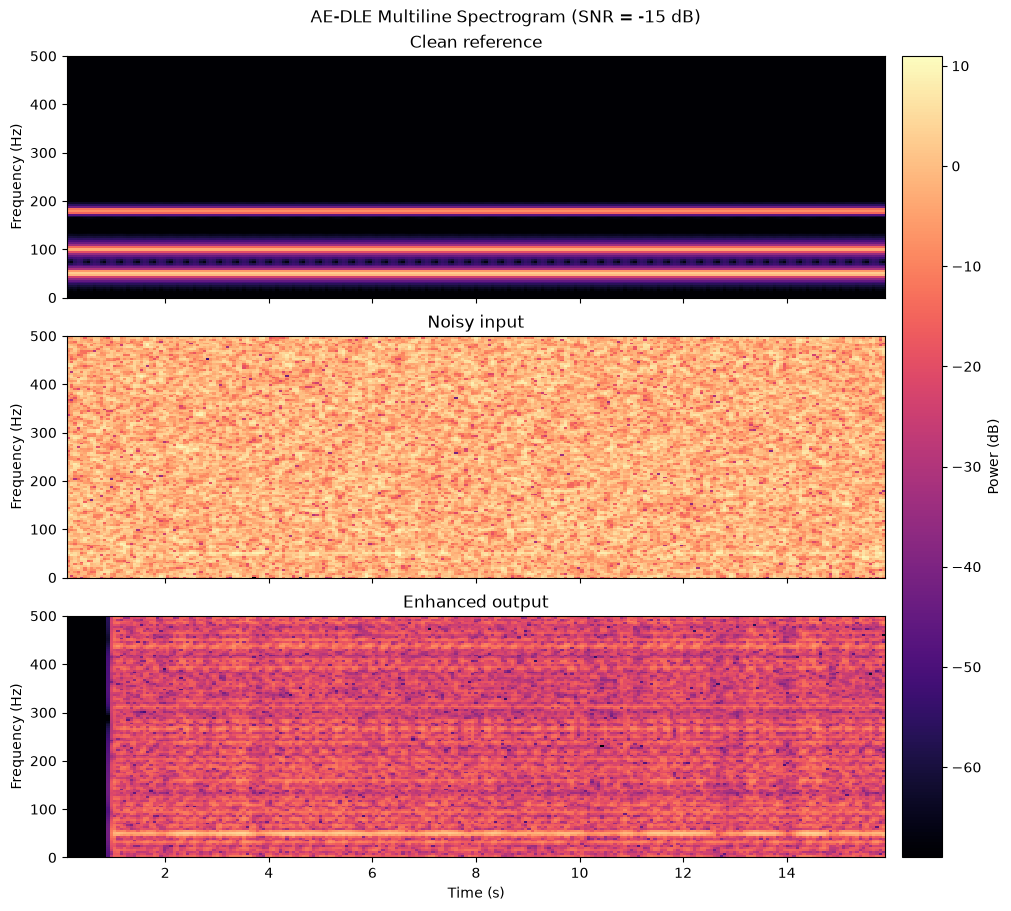

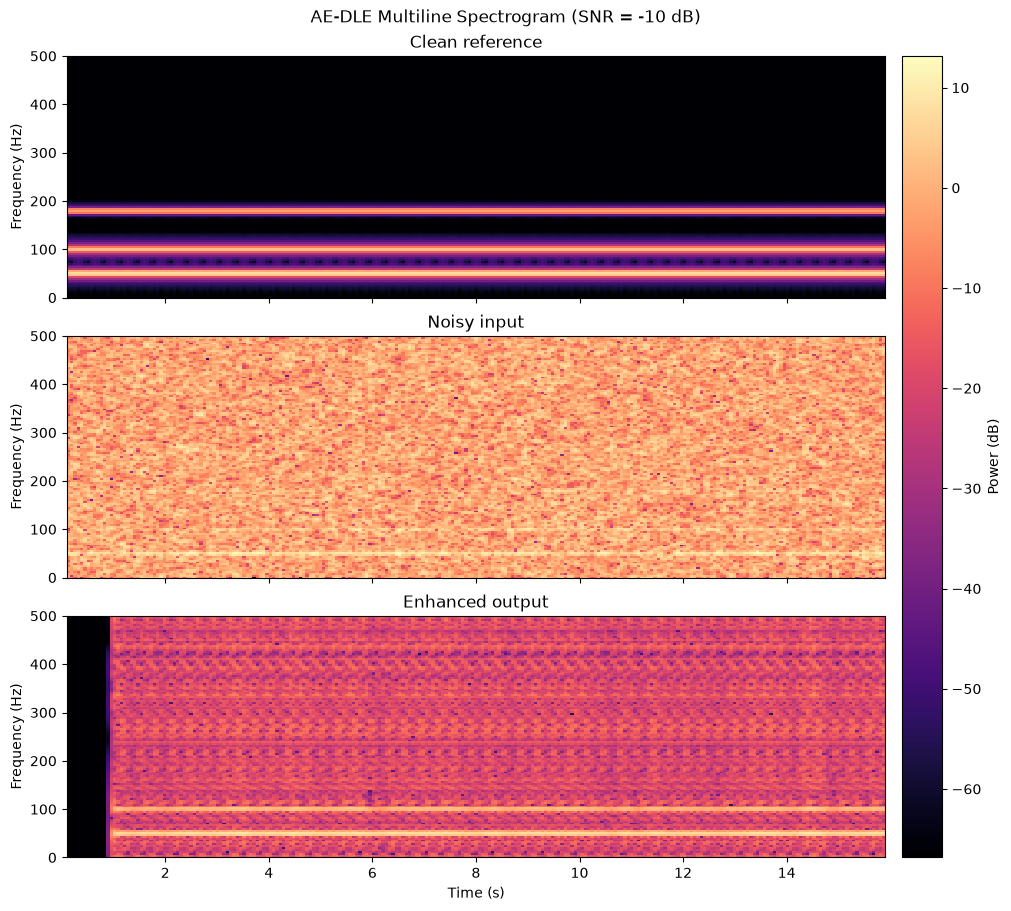

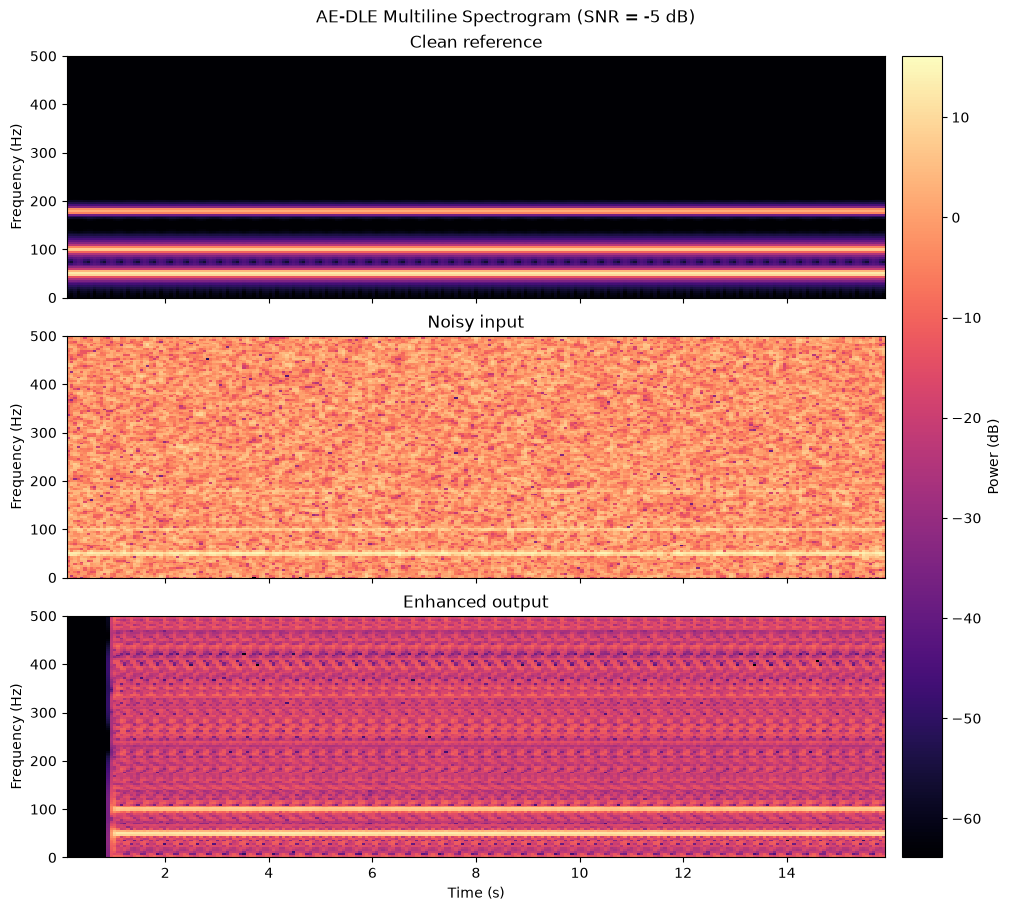

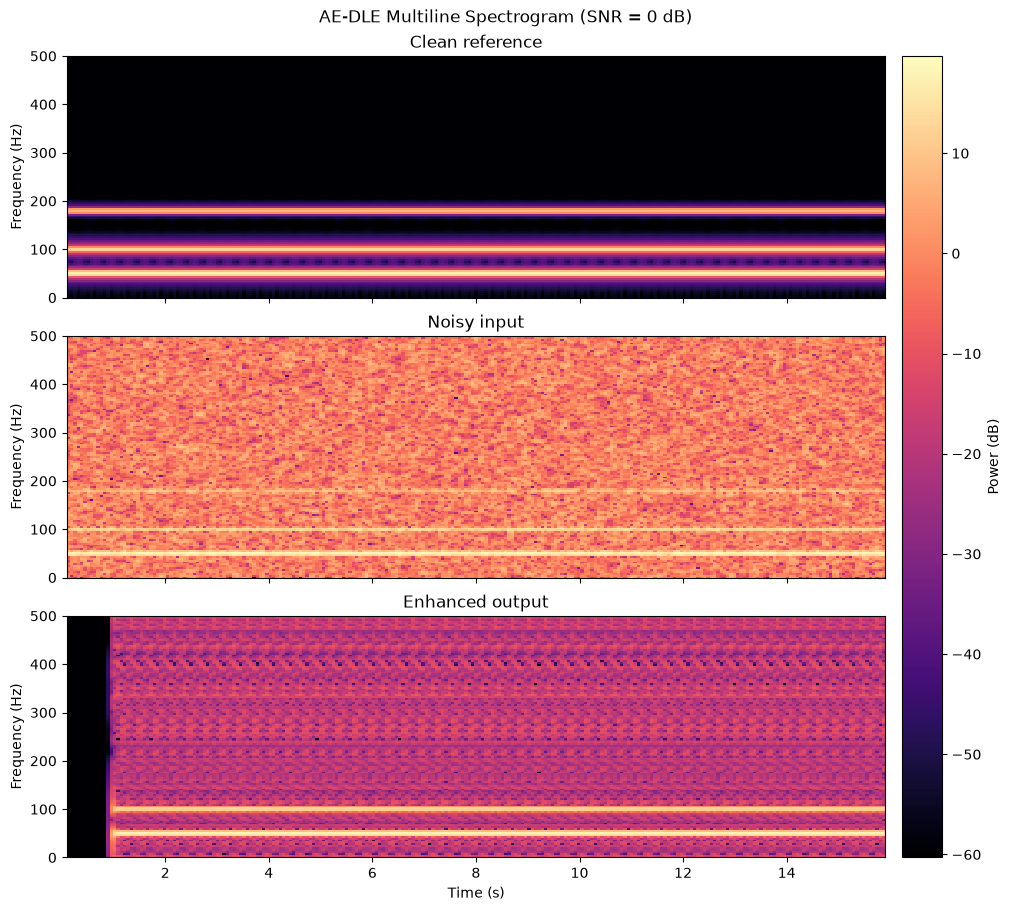

In [27]:
import matplotlib.pyplot as plt

from transformer_based_adaptive_line_enhancer import (
    AEDLEConfig,
    enhance_with_ae_dle,
    generate_noisy_signal,
    plot_line_enhancement_spectrogram,
    train_ae_dle,
)

snr_dbs = [-20, -15, -10, -5, 0]

for snr_db in snr_dbs:
    sample = generate_noisy_signal(
        frequencies_hz=[50.0, 100.0, 180.0],
        amplitudes=[1.0, 0.6, 0.3],
        phases_rad=[0.0, 0.0, 0.0],
        sample_rate_hz=1_000.0,
        num_samples=16_000,
        snr_db=snr_db,
        seed=42,
        scaling="power-normalized",
    )

    config = AEDLEConfig(
        frame_length=256,
        frame_hop=64,
        prediction_delay=1_000,  # 1 kHz 下对应 1 秒
        hidden_dim=128,
        bottleneck_dim=32,
        learning_rate=1e-3,
        batch_size=32,
        epochs=60,
        seed=0,
    )

    training = train_ae_dle(sample.noisy_signal, config=config)
    result = enhance_with_ae_dle(sample.noisy_signal, training)

    figure, axes = plot_line_enhancement_spectrogram(
        sample,
        result.enhanced_signal,
        sample_rate_hz=1_000.0,
        # start_sample=result.valid_start,
        # n_fft=256,
        # hop_length=64,
        # max_frequency_hz=250.0,
        # dynamic_range_db=80.0,
    )

    figure.suptitle(f"AE-DLE Multiline Spectrogram (SNR = {snr_db} dB)")
    figure.savefig(f"ae-dle-multiline-spectrogram-{snr_db}dB.png", dpi=150)
    plt.show()


# AET-DLE 多谱线场景测试


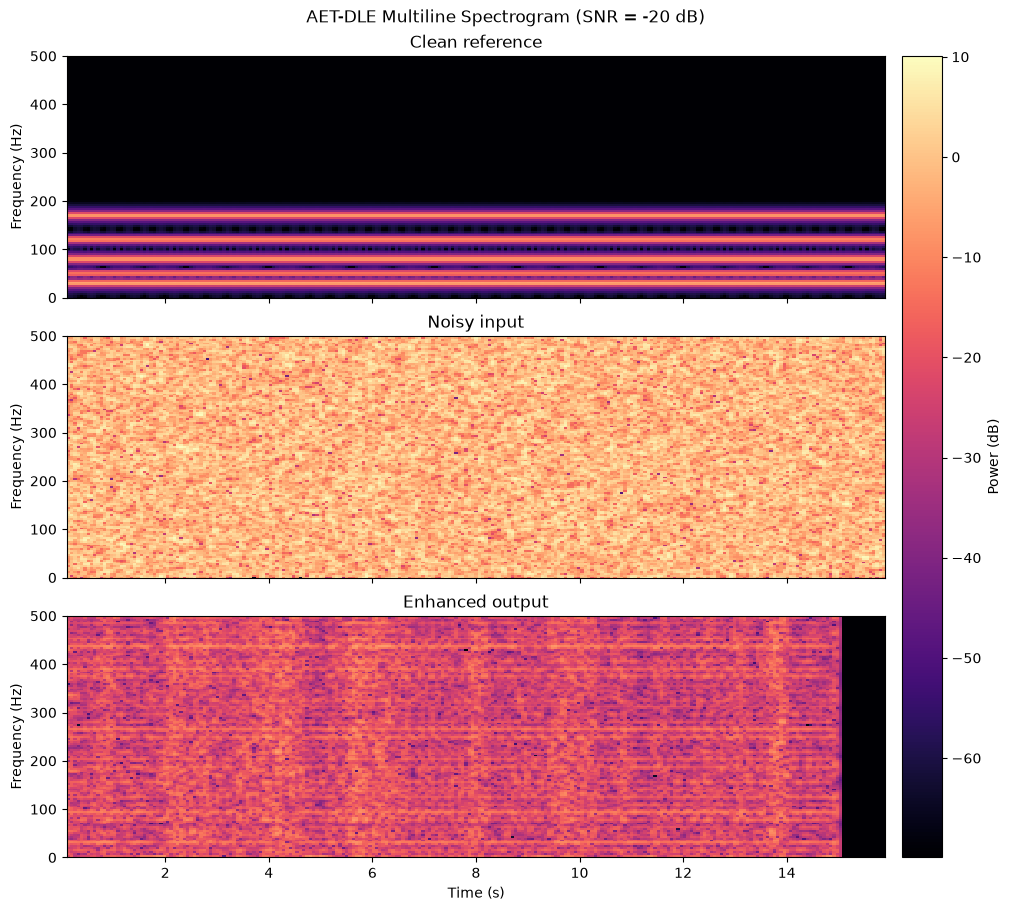

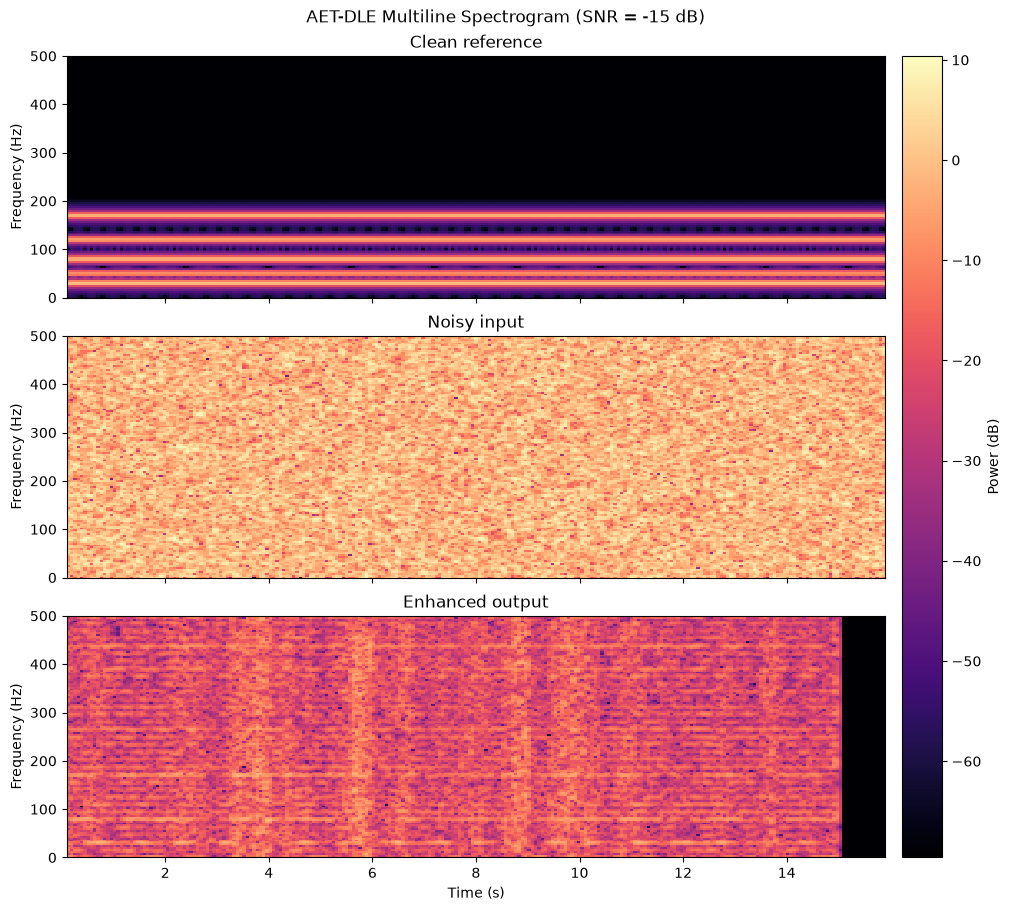

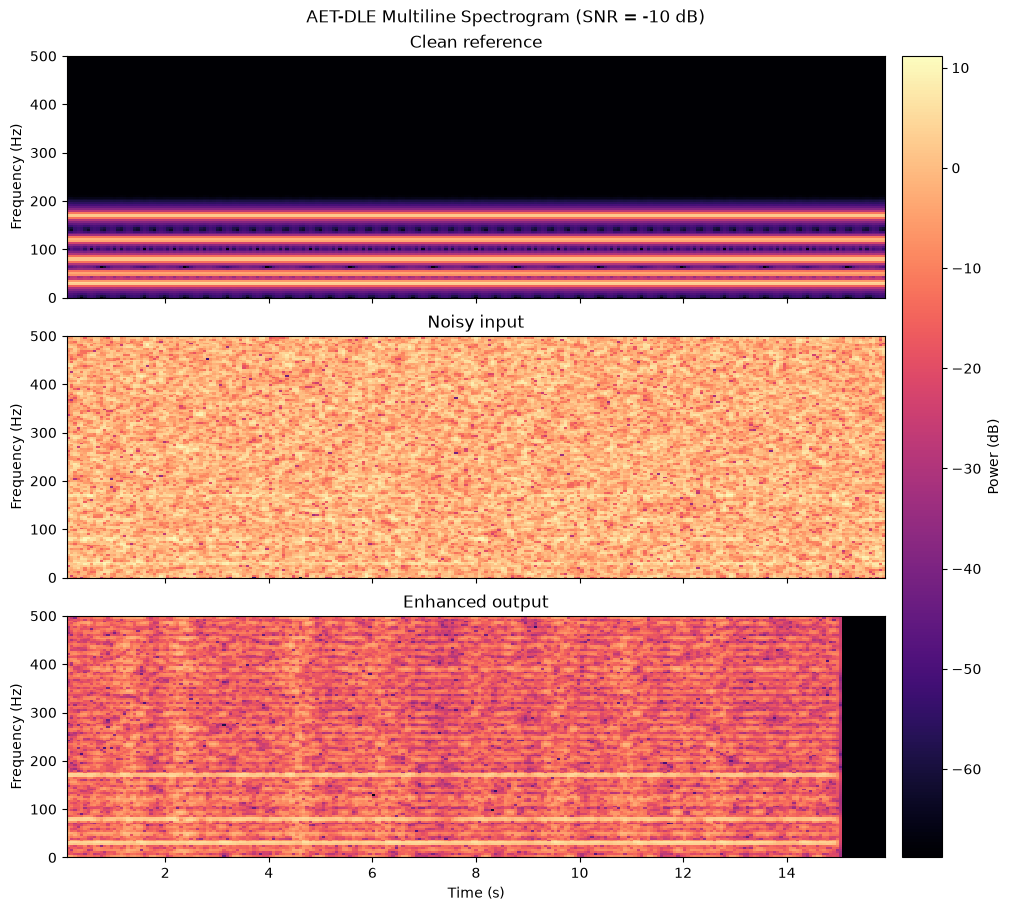

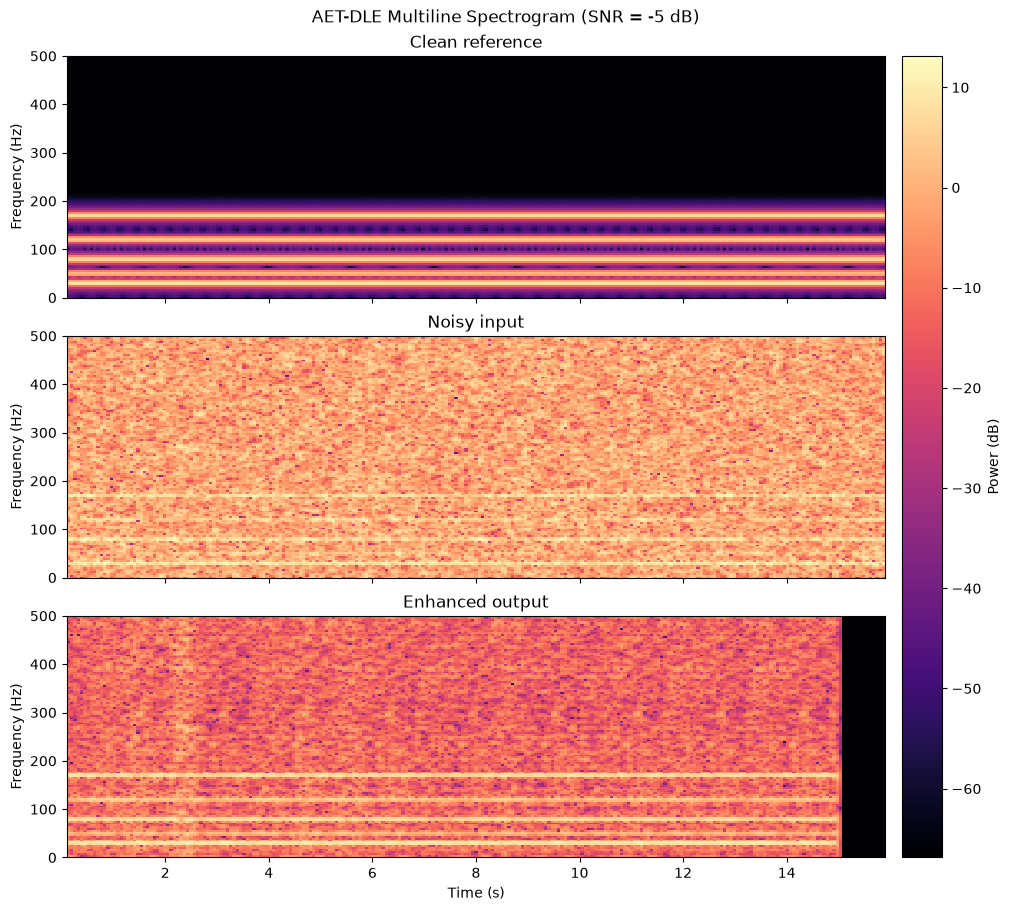

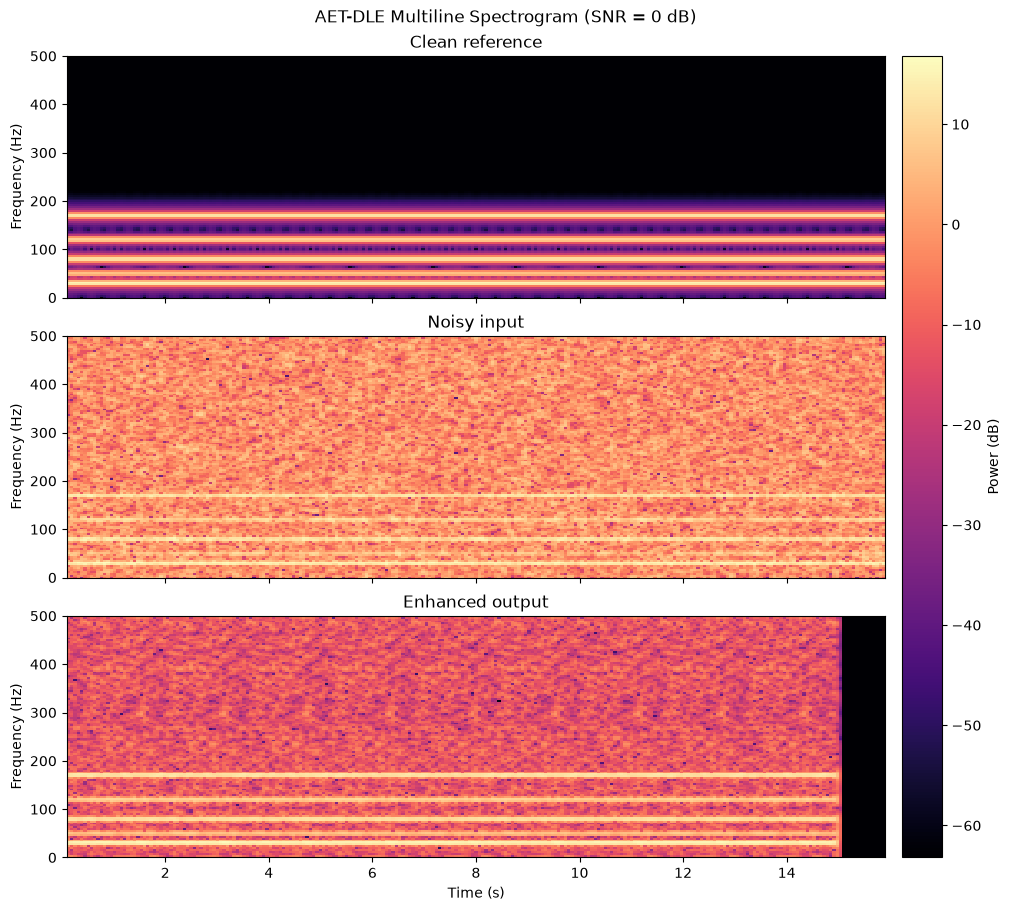

In [4]:
import matplotlib.pyplot as plt

from transformer_based_adaptive_line_enhancer import (
    AETDLEConfig,
    enhance_with_aet_dle,
    generate_noisy_signal,
    plot_line_enhancement_spectrogram,
    train_aet_dle,
)

snr_dbs = [-20, -15, -10, -5, 0]

for snr_db in snr_dbs:
    sample = generate_noisy_signal(
        frequencies_hz=[30, 50, 80, 120, 170],
        amplitudes=[1.4, 0.5, 1, 0.7, 1.1],
        phases_rad=[0.0, 0.0, 0.0, 0.0, 0.0],
        sample_rate_hz=1_000.0,
        num_samples=16_000,
        snr_db=snr_db,
        seed=42,
        scaling="power-normalized",
    )

    config = AETDLEConfig(
        frame_length=320,
        frame_hop=64,
        prediction_delay=1_000,  # 1 kHz 下对应 1 秒
        sequence_length=8,
        embedding_dim=64,
        attention_heads=8,
        transformer_layers=2,
        feedforward_dim=128,
        learning_rate=1e-3,
        batch_size=16,
        epochs=60,
        seed=0,
    )

    training = train_aet_dle(sample.noisy_signal, config=config)
    result = enhance_with_aet_dle(sample.noisy_signal, training)

    figure, axes = plot_line_enhancement_spectrogram(
        sample,
        result.enhanced_signal,
        sample_rate_hz=1_000.0,
    )

    figure.suptitle(f"AET-DLE Multiline Spectrogram (SNR = {snr_db} dB)")
    figure.savefig(f"aet-dle-multiline-spectrogram-{snr_db}dB.png", dpi=150)
    plt.show()
